In [276]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [277]:
df = pd.read_csv(r"C:\Users\ruthe\Documents Local\Adelphe Connect\fife_industry_data.csv")
df.head()

,Industry,Age,Sex,Region,People
0,Agriculture; Forestry; Fishing,Total,Female,Fife,551
1,Agriculture; Forestry; Fishing,16 to 19,Female,Fife,15
2,Agriculture; Forestry; Fishing,20 to 24,Female,Fife,32
3,Agriculture; Forestry; Fishing,25 to 29,Female,Fife,35
4,Agriculture; Forestry; Fishing,30 to 34,Female,Fife,55


In [278]:
#--- Data clean up ---
# Remove unpaid/homecarer work
homecare='Activities of Household as Employers; Undifferentiated Goods - and Services - Producing Activities of Households for Own Use'
df = df.loc[df['Industry'] != homecare]
# Shorten industry names
maximum_character_length=40
for industry in df['Industry'].unique():
    if len(industry) > maximum_character_length:
        print(f"{industry} is too long")

Electricity, Gas, Steam and Air Conditioning Supply is too long
Water Supply; Sewage; Waste Management and Remediation activities is too long
Wholesale and Retail trade; Repair of Motor Vehicles and Motorcycles is too long
Accommodation and Food Service Activities is too long
Professional Scientific and Technical Activities is too long
Administrative and Support Service Activities is too long
Public Administration and Defence; Compulsory Social Security is too long
Activities of Extra-Territorial Organisations and Bodies is too long


In [279]:
industry_replace = {"Electricity, Gas, Steam and Air Conditioning Supply" : "Electricity, Gas, Steam and AC Supply",
                   "Water Supply; Sewage; Waste Management and Remediation activities" : "Water Supply; Sewage; Waste Management",
                   "Wholesale and Retail trade; Repair of Motor Vehicles and Motorcycles" : "Wholesale/Retail trade; Repair of Vehicles",
                   "Accommodation and Food Service Activities" : "Accommodation and Food Service",
                   "Professional Scientific and Technical Activities" : "Scientific and Technical Activities",
                   "Administrative and Support Service Activities" : "Administrative and Support Service",
                   "Public Administration and Defence; Compulsory Social Security": "Administration and Defence; Social Security",
                   "Activities of Extra-Territorial Organisations and Bodies" : "Activities of Extra-Territorial Orgs"}

for i in industry_replace:
    df['Industry'] = df['Industry'].replace(i, industry_replace[i], regex=True)

# Top 3 Industries with the most women

In [280]:
df.loc[(df['Age'] == 'Total') & (df['Sex'] == 'Female')].sort_values(by='People', ascending=False).head(3)[['Industry','People']]

,Industry,People
256,Human Health and Social Work Activities,20489
240,Education,10658
96,Wholesale/Retail trade; Repair of Vehicles,10349


In [281]:
# Make dataframe of just the totals for each industry and sex
# We will separate the Sex column into two new columns: Female_workers and Male_workers
industry_totals = df.loc[(df['Sex'] == 'Female') & (df['Age'] == 'Total')][['Industry', 'People']]
industry_totals.rename(columns={'People': 'Female_workers'}, inplace=True)
industry_totals.set_index('Industry', inplace=True)
industry_totals = pd.merge(industry_totals, df.loc[(df['Sex'] == 'Male') & (df['Age'] == 'Total')][['Industry', 'People']].set_index('Industry'),left_index=True,right_index=True, how='outer')
industry_totals.rename(columns={'People':'Male_workers'}, inplace=True)

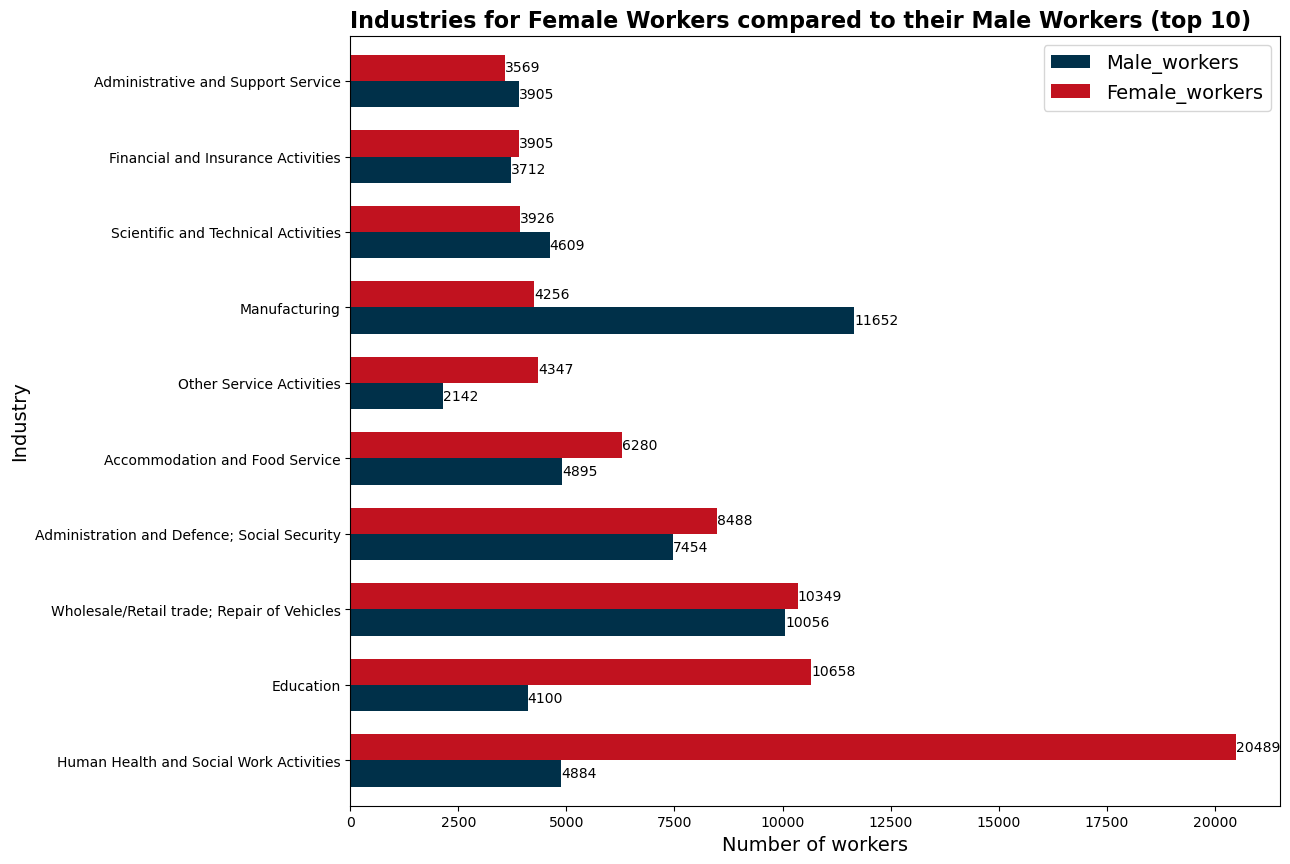

In [293]:
fig, ax = plt.subplots(figsize=(12,10))

industry_totals.sort_values(by='Female_workers', ascending=False, inplace=True)
industry_totals.head(10).plot.barh(width=0.7, y=['Male_workers', 'Female_workers'], stacked=False, 
                                   ax=ax, color={"Female_workers": "#c1121f", "Male_workers": "#003049"})
ax.set_title('Industries for Female Workers compared to their Male Workers (top 10)', fontsize=16, fontweight='bold', loc='left')
ax.set_ylabel('Industry', fontsize=14)
ax.set_xlabel('Number of workers', fontsize=14)
ax.bar_label(ax.containers[0])# Add bar numbers for male bars
ax.bar_label(ax.containers[1])# Add bar number for female bars
ax.legend( fontsize=14)
plt.savefig('top10_Female_Industries.png', dpi=300, bbox_inches='tight')
plt.show()

The Human Health and Social Work industry has the highest amounts of female workers and a high ratio of female-to-male workers, with the Education industry coming in second. 
Other industries lower down in the graph are closer to an equal ratio with the exception of Other Service Activities which has a high female ratio, and Manufacturing which has a low female ratio.

---

# Looking at menopause aged women in the workplace
According to the NHS menopause normally affects women between the ages of 45 to 55.

In the census data ages are grouped together, we can use the '45 to 49' and '50 to 54' age groups to calculate menopause age

In [283]:
df['Menopause age'] = df['Age'].apply(lambda x: True if x == '45 to 55' or x == '50 to 54' else False)

In [284]:
# Count female workers total - only use the totals to avoid double counting 
numerOfFemaleWorkers = df.loc[(df['Sex'] == 'Female') & (df['Age']=='Total')]['People'].sum()
# Count female workers at menopause age
numberOfFemaleWorkersInMenopause = df.loc[(df['Menopause age'] == True) & (df['Sex'] == 'Female')]['People'].sum()
MenopauseAveragePct = numberOfFemaleWorkersInMenopause/numerOfFemaleWorkers
print(f"{numberOfFemaleWorkersInMenopause} out of {numerOfFemaleWorkers} Female workers are at menopause age")
print(f"That's {(MenopauseAveragePct*100).round(2)}%")

10892 out of 84717 Female workers are at menopause age
That's 12.86%


## Top three industries for women at menopause age

In [285]:
df.loc[(df['Menopause age'] == True) & (df['Sex'] == 'Female')].sort_values(by='People', ascending=False).head(3)[['Industry','People']]

,Industry,People
264,Human Health and Social Work Activities,2889
248,Education,1351
232,Administration and Defence; Social Security,1338


Results are simular to the top three industries for all women except instead of Retail at third place, we have public administration and defence.

In [291]:
menopauseAge = df.loc[(df['Sex'] == 'Female') & (df['Menopause age'] == True)].groupby('Industry')['People'].sum()
femalesTotal = df.loc[(df['Sex'] == 'Female') & (df['Age'] == 'Total')].groupby('Industry')['People'].sum()
# Get the top 10 for menopause workers
#menopauseAge = menopauseAge.nlargest(10)
# Add column for percentage of menopause workers
menopauseDf = pd.DataFrame({"Menopause age workers" : menopauseAge, "Total workers" : femalesTotal}, menopauseAge.index)
menopauseDf['Menopause pct'] = menopauseDf.apply(lambda x: (x['Menopause age workers'] / x['Total workers'])*100, axis=1)
menopauseDf.head(3)

,Menopause age workers,Total workers,Menopause pct
Industry,,,
Accommodation and Food Service,471,6280,7.500000
Activities of Extra-Territorial Orgs,10,35,28.571429
Administration and Defence; Social Security,1338,8488,15.763431


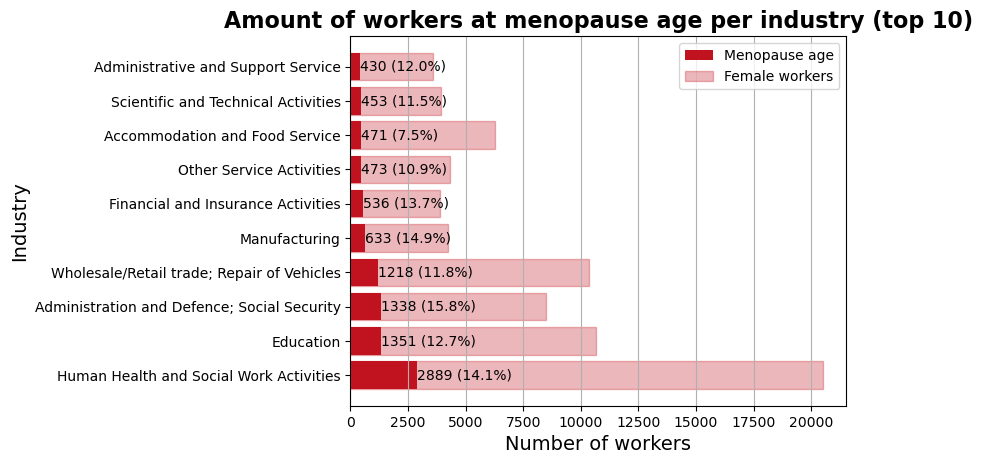

In [294]:
fig, ax = plt.subplots()

top10 = menopauseDf.sort_values(by='Menopause age workers', ascending=False).head(10)

ax.barh(top10.index, top10['Menopause age workers'], color="#c1121f", label='Menopause age')
ax.barh(top10.index, top10['Total workers'], alpha=0.3, color="#c1121f", edgecolor="#c1121f", label='Female workers')
# Create bar labels with amounts and percentages
zipped = zip(ax.containers[0].datavalues, top10['Menopause pct'])
percentage_labels = [f"{z[0]} ({round(z[1],1)}%)" for z in zipped]
ax.bar_label(ax.containers[0], labels=percentage_labels)

ax.set_title('Amount of workers at menopause age per industry (top 10)', fontsize=16, fontweight='bold')
ax.set_ylabel('Industry', fontsize=14)
ax.set_xlabel('Number of workers', fontsize=14)
ax.grid(axis='x')
ax.legend()

plt.savefig('top10_menopause_industries.png', dpi=300, bbox_inches='tight')
plt.show()

This chart shows the count of female workers at menopause age and the percentage of the female workforce they take.

Bars with a percentage higher than 12.86% have an above-average amount of menopause age workers.

### Good targets for Menopause education

- Human Health and Social Work activities

The highest amount of menopause workers are in this industry and they have a slightly higher than average amount of menopause age workers.

- Administration and Defence; Social Security

Has the highest percentage of menopause age workers, although it doesn't have as many workers as other industries it will has a significant amount.

### Poor targets for Menopause education

- Accommodation and Food Service
Has the lowest percentage in the chart with 7.5%, almost half the average.
